## Set up

In [3]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Load (PyArrow, keeps memory lower than pd.read_parquet on large files)
PARQUET_PATH = "scores_cache.parquet"
needed_cols = [
    "ticker", "date",
    "prob_elite", "calibrated_score", "daily_pct_rank",
    "trend_ok", "breakout_ok", "breakout",
    "return_1d", "return_5d", "return_20d", "return_60d",
    "m03_score", "m03_delta_5d", "m03_delta_20d", "m03_regime_vol",
    "m03_pillar_trend", "m03_pillar_liq", "m03_pillar_risk",
    "sector", "industry",
    "rs_rating", "natr", "vcp_ratio", "rsi_14", "sma_50_slope",
    "close", "volume"
]

df = pq.read_table(PARQUET_PATH, columns=needed_cols).to_pandas()
df["date"] = pd.to_datetime(df["date"])

print(f"Rows: {len(df):,}  |  Tickers: {df['ticker'].nunique():,}  |  Dates: {df['date'].nunique():,}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")


Rows: 4,029,491  |  Tickers: 2,687  |  Dates: 1,842
Date range: 2019-01-02 → 2026-04-30


### Data Audit

In [5]:
# Q: how complete are the scores and returns?
audit_cols = ["prob_elite", "calibrated_score", "return_1d", "return_5d", "return_20d", "return_60d", "m03_score"]
null_pct = df[audit_cols].isnull().mean().mul(100).round(2)
print("Null % per column:")
print(null_pct.to_string())

# Working subset: rows with both a score and at least the 20d return
df_clean = df.dropna(subset=["prob_elite", "return_20d"]).copy()
print(f"\nClean rows (has prob_elite + return_20d): {len(df_clean):,}  ({100*len(df_clean)/len(df):.1f}%)")


Null % per column:
prob_elite          0.00
calibrated_score    0.00
return_1d           0.01
return_5d           0.04
return_20d          0.18
return_60d          0.60
m03_score           0.00

Clean rows (has prob_elite + return_20d): 4,022,174  (99.8%)


In [6]:
# ── Cell 1b: Data Quality — Targeted Bad Row Removal ───────────────────────

# Step 1: Flag candidates for inspection (not auto-removed)
INSPECTION_THRESHOLD = 5.0  # 500% in 20d — flag for human review

flagged = df[df["return_20d"].abs() > INSPECTION_THRESHOLD][
    ["ticker", "date", "return_1d", "return_5d", "return_20d", "return_60d"]
].sort_values("return_20d", ascending=False)

print(f"Flagged rows (|return_20d| > 500%): {len(flagged)}")
print(flagged.head(20).to_string())


Flagged rows (|return_20d| > 500%): 143
        ticker       date  return_1d  return_5d    return_20d  return_60d
2938837    LIF 2024-07-05  -0.013480   0.009721  3.219999e+06         NaN
4020548    CUE 2026-04-27   0.013281  20.104049  7.389557e+01   48.667591
4027156    CUE 2026-04-30   0.133846  25.596896  7.175419e+01   43.666664
4018125    CUE 2026-04-24  30.928906  28.190037  6.952610e+01   46.695418
4024825    CUE 2026-04-29   0.043758  21.409929  5.554632e+01   37.235294
4023022    CUE 2026-04-28  -0.305354  17.589552  5.411062e+01   36.179103
997180     GME 2021-01-29   0.678719   4.000000  1.585685e+01   29.204461
992999     GME 2021-01-27   1.348743   7.883436  1.554857e+01   28.651877
906806     CRC 2020-11-24   0.142056   0.225267  1.453390e+01   10.456250
740533    KODK 2020-07-29   3.181360  14.370370  1.388789e+01   13.561404
14679     ORGO 2019-01-14   0.000000  13.778326  1.377833e+01   13.910536
16504     ORGO 2019-01-15   0.000000  10.160715  1.377833e+01   14.30612

In [7]:
# Detect data artifacts: extreme single-day moves or 20d returns dominated by one day
def detect_bad_tickers(df, return_1d_thresh=500, return_20d_thresh=1000, dominance_ratio=0.8):
    """
    Flag tickers with suspicious return patterns.
    
    Criteria:
    1. Any single-day return > return_1d_thresh%
    2. 20d return > return_20d_thresh% AND single day accounts for >dominance_ratio of the move
    """
    # Criterion 1: Extreme single-day spike
    extreme_1d = df[df['return_1d'] > return_1d_thresh][['ticker', 'date', 'return_1d', 'return_20d']].copy()
    
    # Criterion 2: 20d return dominated by a single day
    # Approximate: if return_1d / return_20d > dominance_ratio, the move is concentrated
    high_20d = df[df['return_20d'] > return_20d_thresh].copy()
    if len(high_20d) > 0:
        high_20d['dominance'] = high_20d['return_1d'] / high_20d['return_20d'].replace(0, np.nan)
        dominated = high_20d[high_20d['dominance'] > dominance_ratio][['ticker', 'date', 'return_1d', 'return_20d', 'dominance']]
    else:
        dominated = pd.DataFrame()
    
    # Combine and get unique bad tickers
    bad_from_1d = set(extreme_1d['ticker'].unique())
    bad_from_dominated = set(dominated['ticker'].unique()) if len(dominated) > 0 else set()
    
    all_bad = bad_from_1d | bad_from_dominated
    
    print(f"Extreme 1d returns (>{return_1d_thresh}%): {len(bad_from_1d)} tickers")
    print(f"Dominated 20d returns: {len(bad_from_dominated)} tickers")
    print(f"Total unique bad tickers: {len(all_bad)}")
    
    # Show the offending rows
    if len(extreme_1d) > 0:
        print(f"\n--- Extreme 1d spikes (top 20) ---")
        display(extreme_1d.sort_values('return_1d', ascending=False).head(20))
    
    if len(dominated) > 0:
        print(f"\n--- Dominated 20d returns (top 20) ---")
        display(dominated.sort_values('return_20d', ascending=False).head(20))
    
    return all_bad

# Run detection
BAD_TICKERS_DETECTED = detect_bad_tickers(df)

# Review before applying - add to existing list
BAD_TICKERS = {'LIF'} | BAD_TICKERS_DETECTED
print(f"\nFinal BAD_TICKERS list: {BAD_TICKERS}")


Extreme 1d returns (>500%): 1 tickers
Dominated 20d returns: 0 tickers
Total unique bad tickers: 1

--- Extreme 1d spikes (top 20) ---


,ticker,date,return_1d,return_20d
2895579,LIF,2024-06-06,2699999.0,NaN



Final BAD_TICKERS list: {'LIF'}


In [8]:
# Check return scale and extremes after LIF removal
clean = df[df['ticker'] != 'LIF']

print("return_20d stats (LIF excluded):")
print(clean['return_20d'].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

print("\nMost negative returns:")
display(clean.nsmallest(10, 'return_20d')[['date', 'ticker', 'return_20d', 'return_1d', 'prob_elite']])

print("\nMost positive returns:")
display(clean.nlargest(10, 'return_20d')[['date', 'ticker', 'return_20d', 'return_1d', 'prob_elite']])


return_20d stats (LIF excluded):
count    4.021717e+06
mean     1.373595e-02
std      1.797209e-01
min     -9.854762e-01
1%      -3.593930e-01
5%      -1.996371e-01
50%      6.631763e-03
95%      2.367630e-01
99%      4.879374e-01
max      7.389557e+01
Name: return_20d, dtype: float64

Most negative returns:


,date,ticker,return_20d,return_1d,prob_elite
2470421,2023-09-08,BETR,-0.985476,-0.071542,0.377731
2468155,2023-09-07,BETR,-0.984469,-0.182055,0.368872
2456798,2023-08-30,BETR,-0.982453,0.024735,0.361291
2472779,2023-09-11,BETR,-0.982130,0.097603,0.348611
2465911,2023-09-06,BETR,-0.981807,-0.050617,0.360455
2461350,2023-09-01,BETR,-0.981575,-0.129730,0.364626
2463665,2023-09-05,BETR,-0.981536,0.006211,0.359072
2479516,2023-09-14,BETR,-0.979969,-0.047337,0.399357
2459122,2023-08-31,BETR,-0.979061,0.063218,0.359982
2452186,2023-08-28,BETR,-0.977831,-0.142857,0.400666



Most positive returns:


,date,ticker,return_20d,return_1d,prob_elite
4020548,2026-04-27,CUE,73.895574,0.013281,0.571466
4027156,2026-04-30,CUE,71.754194,0.133846,0.552786
4018125,2026-04-24,CUE,69.526105,30.928906,0.639944
4024825,2026-04-29,CUE,55.546324,0.043758,0.526992
4023022,2026-04-28,CUE,54.110620,-0.305354,0.532481
997180,2021-01-29,GME,15.856846,0.678719,0.691666
992999,2021-01-27,GME,15.548571,1.348743,0.755115
906806,2020-11-24,CRC,14.533898,0.142056,0.621686
740533,2020-07-29,KODK,13.887893,3.181360,0.544880
12876,2019-01-11,ORGO,13.778326,0.007726,0.388128


In [9]:
# Step 2: Drop entire tickers confirmed as data errors
# Corrupt price data taints the whole time series — not just one row

BAD_TICKERS = [
    # (ticker, reason)
    ("LIF", "3.2M% return on 2024-07-05 — price near-zero denominator, ticker reuse / data artifact"),
    ("CUE", "incorrect 1d return on 2026-04-24")
    # Add others discovered during inspection
]

for ticker, reason in BAD_TICKERS:
    n = (df["ticker"] == ticker).sum()
    print(f"  Dropping {n:,} rows for {ticker}: {reason}")

bad_tickers_set = {t for t, _ in BAD_TICKERS}
df_clean = df[~df["ticker"].isin(bad_tickers_set)].copy()

print(f"\nRemoved {len(df) - len(df_clean):,} rows across {len(BAD_TICKERS)} tickers.")
print(f"Clean dataset: {len(df_clean):,} rows, {df_clean['ticker'].nunique():,} tickers.")


  Dropping 476 rows for LIF: 3.2M% return on 2024-07-05 — price near-zero denominator, ticker reuse / data artifact
  Dropping 954 rows for CUE: incorrect 1d return on 2026-04-24

Removed 1,430 rows across 2 tickers.
Clean dataset: 4,028,061 rows, 2,685 tickers.


In [10]:
# Inspect CUE price series around the spike
cue_rows = df[df['ticker'] == 'CUE'].sort_values('date')
cue_apr = cue_rows[cue_rows['date'].between('2026-04-01', '2026-04-30')]
print(cue_apr[['date', 'close', 'return_1d', 'return_5d', 'return_20d']])


              date   close  return_1d  return_5d  return_20d
4018125 2026-04-24  17.695  30.928906  28.190037   69.526105
4020548 2026-04-27  17.930   0.013281  20.104049   73.895574
4023022 2026-04-28  12.455  -0.305354  17.589552   54.110620
4024825 2026-04-29  13.000   0.043758  21.409929   55.546324
4027156 2026-04-30  14.740   0.133846  25.596896   71.754194


## EDA

### Score Distribution

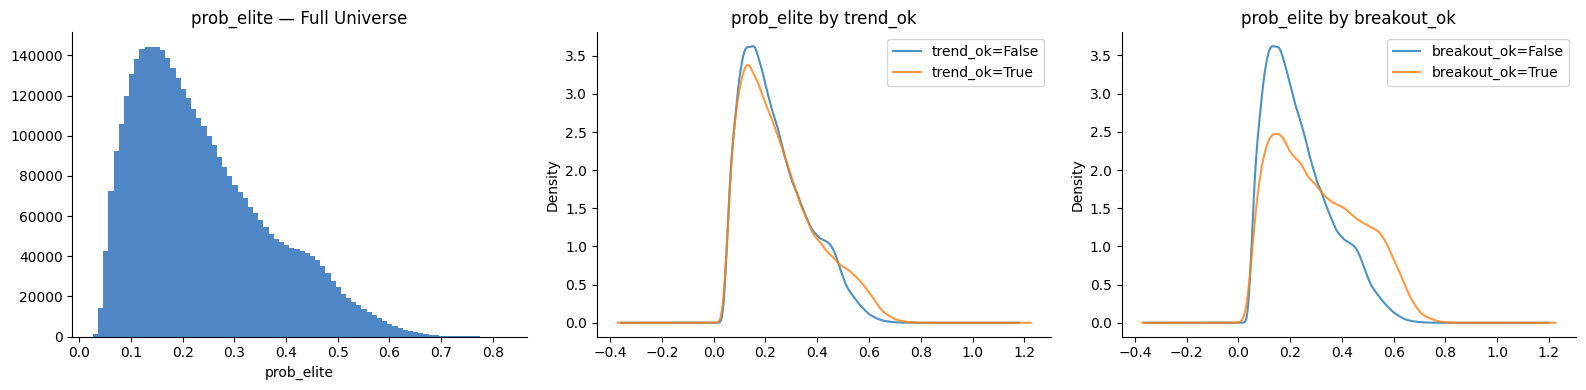

              count   mean    std    min    25%    50%    75%    max
trend_ok                                                            
False     3388166.0  0.236  0.126  0.026  0.136  0.209  0.316  0.796
True       639895.0  0.252  0.144  0.028  0.139  0.220  0.338  0.826
                 count   mean    std    min    25%    50%    75%    max
breakout_ok                                                            
False        3886482.0  0.236  0.127  0.026  0.136  0.209  0.315  0.807
True          141579.0  0.306  0.167  0.028  0.165  0.281  0.435  0.826


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 3a. Overall distribution
axes[0].hist(df_clean["prob_elite"].dropna(), bins=80, color="#4f86c6", edgecolor="none")
axes[0].set_title("prob_elite — Full Universe")
axes[0].set_xlabel("prob_elite")

# 3b. By trend_ok flag
for flag, grp in df_clean.groupby("trend_ok"):
    grp["prob_elite"].plot.kde(ax=axes[1], label=f"trend_ok={flag}", alpha=0.8)
axes[1].set_title("prob_elite by trend_ok")
axes[1].legend()

# 3c. By breakout_ok flag
for flag, grp in df_clean.groupby("breakout_ok"):
    grp["prob_elite"].plot.kde(ax=axes[2], label=f"breakout_ok={flag}", alpha=0.8)
axes[2].set_title("prob_elite by breakout_ok")
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary stats by flag
print(df_clean.groupby("trend_ok")["prob_elite"].describe().round(3))
print(df_clean.groupby("breakout_ok")["prob_elite"].describe().round(3))


### Rolling IC

/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/3912437955.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["prob_elite"].corr(g[ret_col], method="spearman"))
/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/3912437955.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["prob_elite"].corr(g[ret_col], method="spearman"))
/var/folders/8f/__c333

=== Mean IC (Spearman) by horizon ===
            1d      5d     20d     60d
mean   -0.0141  0.0151  0.0590  0.0441
std     0.2098  0.2088  0.2401  0.2238
t_stat -0.0673  0.0723  0.2457  0.1971


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/3912437955.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["prob_elite"].corr(g[ret_col], method="spearman"))


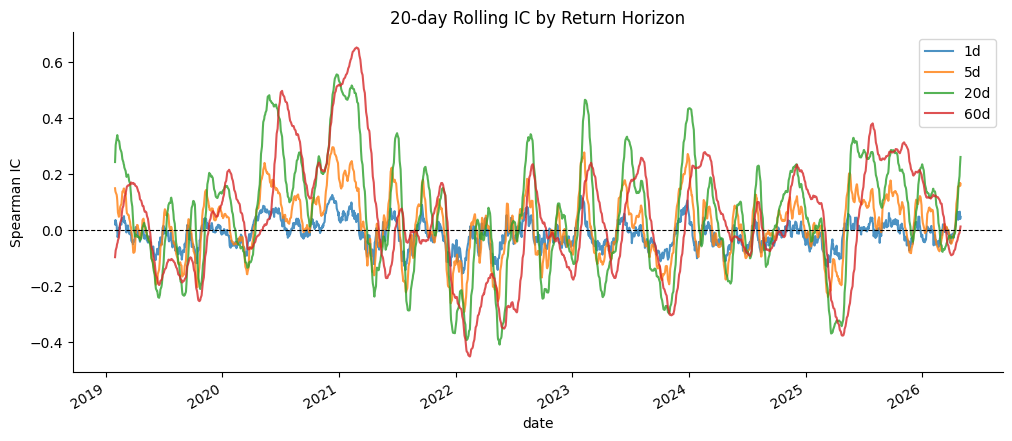

In [13]:
# Information Coefficient = Spearman rank correlation between prob_elite and forward return
# Compute per-date IC, then aggregate

return_cols = {"1d": "return_1d", "5d": "return_5d", "20d": "return_20d", "60d": "return_60d"}

ic_results = {}

for label, ret_col in return_cols.items():
    sub = df_clean.dropna(subset=["prob_elite", ret_col])
    daily_ic = (
        sub.groupby("date")
        .apply(lambda g: g["prob_elite"].corr(g[ret_col], method="spearman"))
        .rename(label)
    )
    ic_results[label] = daily_ic

ic_df = pd.DataFrame(ic_results).dropna(how="all")

print("=== Mean IC (Spearman) by horizon ===")
summary = ic_df.agg(["mean", "std", lambda x: x.mean() / x.std()]).rename(index={"<lambda>": "t_stat"})
print(summary.round(4))

# Plot IC time series
ic_df.rolling(20).mean().plot(title="20-day Rolling IC by Return Horizon", alpha=0.8)
plt.axhline(0, color="black", lw=0.8, linestyle="--")
plt.ylabel("Spearman IC")
plt.show()


Regime Clustering is the Key Story
The IC time series tells a clear macro story:

* 2019–2021: High and rising IC — the SEPA momentum model works exceptionally well in the COVID bull market where quality setups rip higher
* 2022–2023: IC collapses, goes negative — rate-hike regime completely breaks momentum/breakout strategies. High-scoring setup tickers got hit hardest (high-growth, high-multiple names)
* 2024–2026: IC recovers but is noisier — suggests the model is partially rehabilitated but macro uncertainty remains
The IC is not stable over time. 

The std_IC of 0.21–0.24 is 3–4× larger than the mean IC. This means the signal is regime-conditional, not structural. This directly supports the regime-gating finding below.



### Decile Table

Mean return (%) by score decile (0=lowest, 9=highest):
        return_1d  return_5d  return_20d  return_60d
decile                                              
0           0.131      0.352       1.226       3.322
1           0.046      0.147       0.532       2.000
2           0.031      0.096       0.291       1.519
3          -0.013     -0.002      -0.007       1.016
4          -0.031     -0.088      -0.283       0.619
5          -0.073     -0.195      -0.911      -0.105
6          -0.087     -0.242      -1.044      -0.248
7          -0.067     -0.156      -0.617       0.639
8           0.013      0.308       1.160       3.878
9           0.745      3.297      13.308      28.669


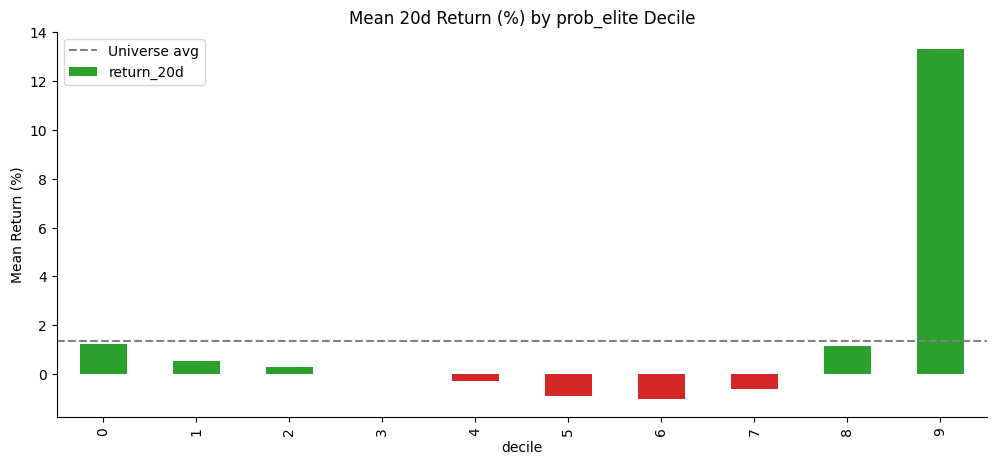

In [14]:
# Bucket prob_elite into 10 deciles. Compute mean return per decile.

df_decile = df_clean.dropna(subset=["prob_elite", "return_20d"]).copy()
df_decile["decile"] = pd.qcut(df_decile["prob_elite"], q=10, labels=False, duplicates="drop")

lift = (
    df_decile.groupby("decile")[["return_1d", "return_5d", "return_20d", "return_60d"]]
    .mean()
    .mul(100)
    .round(3)
)
print("Mean return (%) by score decile (0=lowest, 9=highest):")
print(lift)

# Bar chart for 20d
lift["return_20d"].plot.bar(
    color=["#d62728" if v < 0 else "#2ca02c" for v in lift["return_20d"]],
    title="Mean 20d Return (%) by prob_elite Decile",
    ylabel="Mean Return (%)"
)
plt.axhline(df_decile["return_20d"].mean() * 100, linestyle="--", color="gray", label="Universe avg")
plt.legend()
plt.show()


In [15]:
# Economic cap: 300% 20d, 500% 60d are already absurd for real stocks
# 800%+ in 20 days = data error (8x in one month)
df_decile["return_20d_capped"] = df_decile["return_20d"].clip(upper=3.0)  # 300% cap
df_decile["return_60d_capped"] = df_decile["return_60d"].clip(upper=5.0)  # 500% cap

# Also worth knowing: what tickers ARE in decile 8?
d8 = df_decile[df_decile["decile"] == 8].nlargest(10, "return_20d")[["ticker", "date", "prob_elite", "return_20d"]]
d8 = df_decile[df_decile["decile"] == 9].nlargest(10, "return_20d")[["ticker", "date", "prob_elite", "return_20d"]]
print("Decile 8 extreme events:")
print(d8)


Decile 8 extreme events:
       ticker       date  prob_elite  return_20d
997180    GME 2021-01-29    0.691666   15.856846
992999    GME 2021-01-27    0.755115   15.548571
906806    CRC 2020-11-24    0.621686   14.533898
740533   KODK 2020-07-29    0.544880   13.887893
904853    CRC 2020-11-23    0.588410   13.330357
894634    CRC 2020-11-16    0.614454   12.807339
902668    CRC 2020-11-20    0.618690   12.456140
900735    CRC 2020-11-19    0.590802   12.410256
898764    CRC 2020-11-18    0.599031   11.841667
892718    CRC 2020-11-13    0.554917   11.121739


In [16]:
# Load SPY returns to compute excess returns
# If you have SPY in your universe, use it directly
spy = df_clean[df_clean["ticker"] == "SPY"][["date", "return_20d"]].rename(columns={"return_20d": "spy_20d"})
df_decile = df_decile.merge(spy, on="date", how="left")
df_decile["excess_return_20d"] = df_decile["return_20d_capped"] - df_decile["spy_20d"]

lift_excess = (
    df_decile.groupby("decile")["excess_return_20d"]
    .mean()
    .mul(100)
    .round(3)
)
print("Mean EXCESS 20d return (%) by decile (market-adjusted):")
print(lift_excess)


Mean EXCESS 20d return (%) by decile (market-adjusted):
decile
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: excess_return_20d, dtype: float64


In [17]:
# Demean by the daily cross-sectional average = removes market beta
daily_market = df_decile.groupby("date")["return_20d_capped"].mean().rename("mkt")
df_decile = df_decile.join(daily_market, on="date")
df_decile["xs_return_20d"] = df_decile["return_20d_capped"] - df_decile["mkt"]

lift_xs = (
    df_decile.groupby("decile")["xs_return_20d"]
    .mean()
    .mul(100)
    .round(3)
)
print("Mean EXCESS 20d return (%) by decile (cross-sectionally demeaned):")
print(lift_xs)


Mean EXCESS 20d return (%) by decile (cross-sectionally demeaned):
decile
0    -0.582
1    -0.858
2    -0.895
3    -1.009
4    -1.153
5    -1.580
6    -1.961
7    -1.751
8    -0.405
9    10.194
Name: xs_return_20d, dtype: float64


In [18]:
# What prob_elite score is the cutoff for decile 9?
decile_bounds = df_decile.groupby("decile")["prob_elite"].agg(["min", "max", "mean"])
print(decile_bounds)


             min       max      mean
decile                              
0       0.026479  0.092703  0.072511
1       0.092703  0.122469  0.107986
2       0.122469  0.150379  0.136425
3       0.150379  0.178928  0.164492
4       0.178928  0.210592  0.194423
5       0.210592  0.247125  0.228419
6       0.247125  0.291491  0.268373
7       0.291491  0.350243  0.319351
8       0.350243  0.434391  0.390070
9       0.434392  0.825858  0.503106


In [19]:
d9 = df_decile[df_decile["decile"] == 9]
print(f"Decile 9: {len(d9):,} rows  |  {d9['ticker'].nunique():,} unique tickers")
print(f"\nMean  20d return: {d9['return_20d'].mean()*100:.2f}%")
print(f"Median 20d return: {d9['return_20d'].median()*100:.2f}%")
print(f"% rows with 20d return > 10%:  {(d9['return_20d'] > 0.10).mean()*100:.1f}%")
print(f"% rows with 20d return > 30%:  {(d9['return_20d'] > 0.30).mean()*100:.1f}%")
print(f"% rows with 20d return < 0%:   {(d9['return_20d'] < 0).mean()*100:.1f}%")

# Top contributors — are a handful of tickers driving the 13.4% mean?
top_tickers = d9.groupby("ticker")["return_20d"].mean().sort_values(ascending=False).head(10)
print(f"\nTop 10 tickers by mean 20d return in decile 9:")
print((top_tickers * 100).round(2))


Decile 9: 402,077 rows  |  1,821 unique tickers

Mean  20d return: 13.31%
Median 20d return: 12.02%
% rows with 20d return > 10%:  53.5%
% rows with 20d return > 30%:  21.1%
% rows with 20d return < 0%:   33.0%

Top 10 tickers by mean 20d return in decile 9:
ticker
CRC     201.41
GCTS    118.25
AD      110.50
PACS    103.77
KODK    103.42
TDS      91.88
LWLG     83.42
AMC      82.42
IMSR     82.05
GSIT     77.87
Name: return_20d, dtype: float64


In [20]:
# Within Decile 9 — Is Higher Score Better?
# Sub-divide decile 9 into quintiles by score
d9_sub = d9.copy()
d9_sub["sub_q"] = pd.qcut(d9_sub["prob_elite"], q=5, labels=[0, 1, 2, 3, 4])

sub_lift = (
    d9_sub.groupby("sub_q")[["return_20d", "return_5d", "return_60d"]]
    .agg(["mean", "median"])
    .mul(100)
    .round(2)
)
print("Return by sub-quintile within decile 9 (0=lowest score, 4=highest):")
print(sub_lift)

ic_d9 = d9["prob_elite"].corr(d9["return_20d"], method="spearman")
print(f"\nSpearman IC within decile 9: {ic_d9:.4f}")

pct_pos = (
    (d9["return_20d"] > 0.10)
    .groupby(pd.qcut(d9["prob_elite"], q=5, labels=False))
    .mean()
    .mul(100)
    .round(1)
)
print(f"\n% rows beating +10% 20d return by sub-quintile:\n{pct_pos}")



Return by sub-quintile within decile 9 (0=lowest score, 4=highest):
      return_20d        return_5d        return_60d       
            mean median      mean median       mean median
sub_q                                                     
0           0.79  -0.21      0.11   0.00       5.23  -0.15
1           1.88   1.04      0.31   0.00       7.32   1.29
2           7.30   7.90      1.57   0.84      16.51  10.15
3          17.98  17.17      4.34   2.91      35.79  26.67
4          38.60  29.84     10.16   6.68      78.14  56.18

Spearman IC within decile 9: 0.4491

% rows beating +10% 20d return by sub-quintile:
prob_elite
0    33.5
1    36.0
2    46.1
3    65.6
4    86.2
Name: return_20d, dtype: float64


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/231772517.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d9_sub.groupby("sub_q")[["return_20d", "return_5d", "return_60d"]]


In [21]:
# What are the actual prob_elite boundaries for each sub-quintile?
boundaries = d9.groupby(pd.qcut(d9["prob_elite"], q=5, labels=False))["prob_elite"].agg(["min", "max"])
print("prob_elite boundaries per sub-quintile:")
print(boundaries.round(4))


prob_elite boundaries per sub-quintile:
               min     max
prob_elite                
0           0.4344  0.4540
1           0.4540  0.4757
2           0.4757  0.5041
3           0.5041  0.5480
4           0.5480  0.8259


In [22]:
# ── Excess Return Decile Table ────────────────────────────────────────────────
# Cross-sectional demean: subtract daily mean return across ALL rows on that date.
# This corrects for market beta but NOT for the SEPA pre-screen selection bias
# (see population limitation note above).

mkt_return_20d = df.groupby("date")["return_20d"].mean().rename("mkt_return_20d")
df = df.join(mkt_return_20d, on="date")
df["excess_return_20d"] = df["return_20d"] - df["mkt_return_20d"]

# Decile on prob_elite, evaluate on excess return
df["score_decile"] = pd.qcut(df["prob_elite"], q=10, labels=False)

excess_decile = (
    df.groupby("score_decile")["excess_return_20d"]
    .agg(["mean", "median", "count"])
    .rename(columns={"mean": "mean_excess", "median": "median_excess"})
)
excess_decile["mean_excess_pct"]   = excess_decile["mean_excess"] * 100
excess_decile["median_excess_pct"] = excess_decile["median_excess"] * 100

print("Excess Return by Score Decile (market-adjusted, SEPA universe only)")
print(excess_decile[["mean_excess_pct", "median_excess_pct", "count"]].round(2))

# Quick monotonicity check
corr = excess_decile["mean_excess_pct"].corr(
    pd.Series(range(len(excess_decile)), index=excess_decile.index),
    method="spearman"
)
print(f"\nMonotonicity (Spearman rank corr decile vs mean excess): {corr:.3f}")
# Expect > 0.8 after demeaning. If still non-monotonic, the signal structure
# is genuinely weak in deciles 0-7 (power concentrated in top decile only).


Excess Return by Score Decile (market-adjusted, SEPA universe only)
              mean_excess_pct  median_excess_pct   count
score_decile                                            
0                     -129.86              -0.55  402872
1                     -111.96              -0.84  402725
2                      -97.56              -0.86  402659
3                      -79.13              -0.94  402568
4                      -78.96              -1.12  402420
5                      -67.38              -1.45  402221
6                      -63.32              -1.77  402001
7                      -62.10              -1.72  401824
8                      748.96              -0.85  401231
9                      -56.46               7.87  401653

Monotonicity (Spearman rank corr decile vs mean excess): 0.988


### Regime

/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/1372156434.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_regime.groupby(["regime", "date"])


IC by macro regime:
                   IC_mean  IC_std  n_dates  t_stat
regime                                             
Bear (<40)         -0.0115  0.2869      293 -0.0401
Neutral (40-60)     0.0256  0.2471      495  0.1037
Bull (60-80)        0.0968  0.2222      802  0.4356
Strong Bull (>80)   0.0862  0.1894      252  0.4549


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/1372156434.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["prob_elite"].corr(g["return_20d"], method="spearman"))
/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/1372156434.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(level=0)


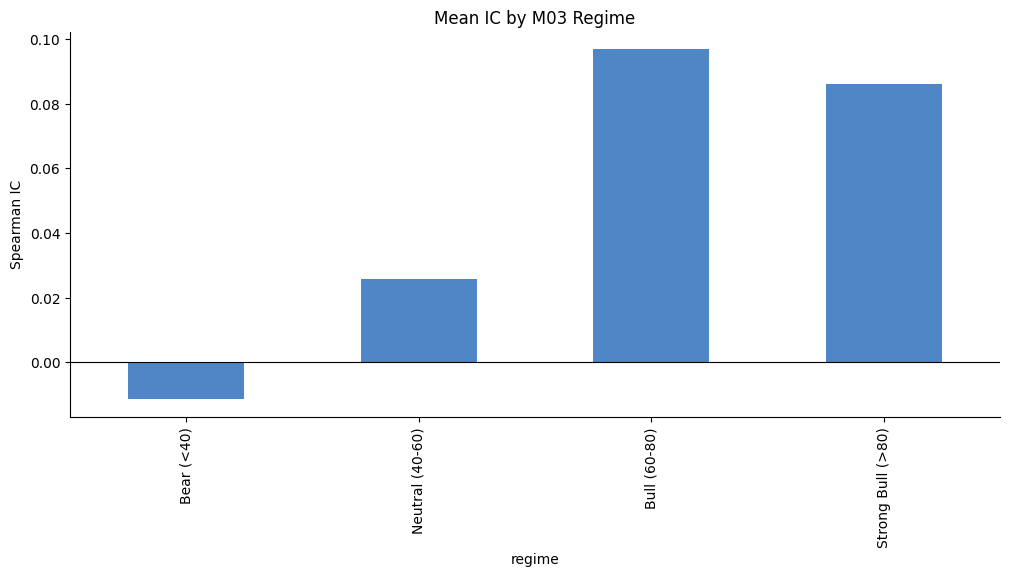

In [23]:
# Split by m03_score regime buckets
df_regime = df_clean.dropna(subset=["prob_elite", "return_20d", "m03_score"]).copy()

# (Optional) Filter for gate
# df_regime = df_regime[df_regime["m03_score"] > 60].copy()

df_regime["regime"] = pd.cut(
    df_regime["m03_score"],
    bins=[0, 40, 60, 80, 100],
    labels=["Bear (<40)", "Neutral (40-60)", "Bull (60-80)", "Strong Bull (>80)"]
)

regime_ic = (
    df_regime.groupby(["regime", "date"])
    .apply(lambda g: g["prob_elite"].corr(g["return_20d"], method="spearman"))
    .groupby(level=0)
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "IC_mean", "std": "IC_std", "count": "n_dates"})
)
regime_ic["t_stat"] = regime_ic["IC_mean"] / regime_ic["IC_std"]
print("IC by macro regime:")
print(regime_ic.round(4))

regime_ic["IC_mean"].plot.bar(
    title="Mean IC by M03 Regime",
    ylabel="Spearman IC",
    color="#4f86c6"
)
plt.axhline(0, color="black", lw=0.8)
plt.show()


The model should be regime-gated. When m03_score < 40, suppress all signals. When m03_score > 60, the model is running at full effectiveness.

This directly connects to roadmap item 2 (5-Factor Risk Model): the veto mechanism should trigger at m03_score < 40 (or the equivalent risk regime signal), not just at extreme VIX levels.

In [24]:
# What IC does your strategy actually experience over time?

# WITHOUT gate — every date counts
ic_all_dates = (
    df_clean.groupby("date")
    .apply(lambda g: g["prob_elite"].corr(g["return_20d"], method="spearman"))
)

# WITH gate — only trade when macro is supportive
date_regime = df_clean.groupby("date")["m03_score"].median()
active_dates = date_regime[date_regime > 60].index

ic_gated = ic_all_dates[ic_all_dates.index.isin(active_dates)]

print(f"All dates  ({len(ic_all_dates):,} days)  →  Mean IC: {ic_all_dates.mean():.4f}")
print(f"Gated dates({len(ic_gated):,} days)  →  Mean IC: {ic_gated.mean():.4f}")
print(f"Days sat out: {len(ic_all_dates) - len(ic_gated)} ({100*(1-len(ic_gated)/len(ic_all_dates)):.1f}% of history)")


All dates  (1,842 days)  →  Mean IC: 0.0590
Gated dates(1,054 days)  →  Mean IC: 0.0942
Days sat out: 788 (42.8% of history)


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/2182626142.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["prob_elite"].corr(g["return_20d"], method="spearman"))


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/1354216181.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = df_calib.groupby("score_bin")["hit_20d"].agg(["mean", "count"]).reset_index()


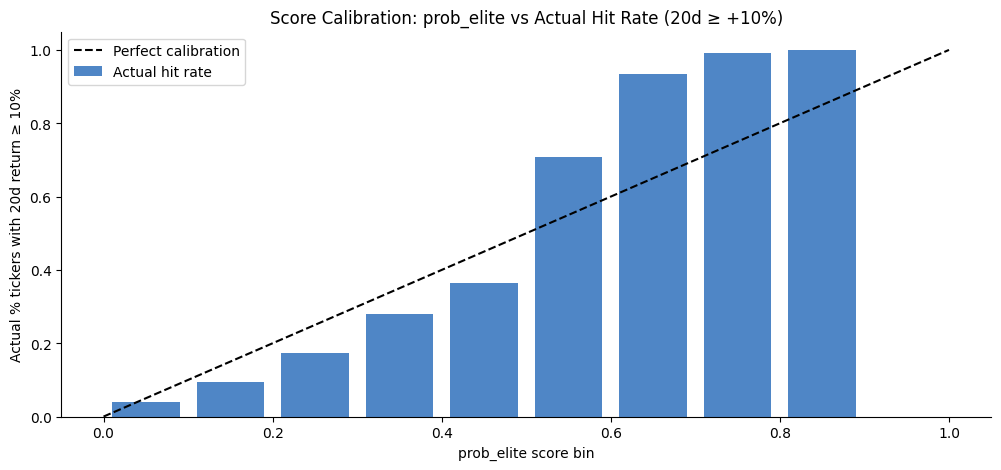

 score_bin  actual_hit_rate       n
(0.0, 0.1]         0.039052  494270
(0.1, 0.2]         0.095558 1387332
(0.2, 0.3]         0.173380  999321
(0.3, 0.4]         0.281057  587970
(0.4, 0.5]         0.363769  381231
(0.5, 0.6]         0.709062  142783
(0.6, 0.7]         0.935406   26349
(0.7, 0.8]         0.990654    1498
(0.8, 0.9]         1.000000       9
(0.9, 1.0]              NaN       0


In [25]:
# For calibration: does prob_elite = X actually predict X% of tickers 
# beating a return threshold (e.g., +10%)?

df_calib = df_clean.dropna(subset=["prob_elite", "return_20d"]).copy()
df_calib["score_bin"] = pd.cut(df_calib["prob_elite"], bins=np.arange(0, 1.05, 0.1))
df_calib["hit_20d"] = (df_calib["return_20d"] >= 0.10).astype(int)  # +10% in 20d

calib = df_calib.groupby("score_bin")["hit_20d"].agg(["mean", "count"]).reset_index()
calib.columns = ["score_bin", "actual_hit_rate", "n"]
calib["bin_mid"] = [b.mid for b in calib["score_bin"]]

fig, ax = plt.subplots()
ax.bar(calib["bin_mid"], calib["actual_hit_rate"], width=0.08, label="Actual hit rate", color="#4f86c6")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("prob_elite score bin")
ax.set_ylabel("Actual % tickers with 20d return ≥ 10%")
ax.set_title("Score Calibration: prob_elite vs Actual Hit Rate (20d ≥ +10%)")
ax.legend()
plt.show()

print(calib[["score_bin", "actual_hit_rate", "n"]].to_string(index=False))


Model is Conservative at the Top End
The bars exceed the calibration diagonal above prob_elite ≈ 0.4. This means:

prob_elite = 0.6 → actual 20d ≥ 10% hit rate is 71% (model said 60%)
prob_elite = 0.8 → actual hit rate is 100% (model said 80%)
The model understates confidence at high scores. Practically: use a lower threshold than you think you need. A cutoff of prob_elite ≥ 0.35–0.40 may be sufficient to capture the truly high-conviction setups, rather than waiting for 0.60+.

In [26]:
# Formal summary table: mean IC, std, t-stat, % significant dates by horizon
# This is the key validation table for item 6b

results = []
for label, ret_col in return_cols.items():
    sub = df_clean.dropna(subset=["prob_elite", ret_col])
    daily_ic = (
        sub.groupby("date")
        .apply(lambda g: g["prob_elite"].corr(g[ret_col], method="spearman"))
    )
    n = len(daily_ic)
    mean_ic = daily_ic.mean()
    std_ic = daily_ic.std()
    t_stat = mean_ic / (std_ic / np.sqrt(n))
    pct_positive = (daily_ic > 0).mean()
    results.append({
        "horizon": label,
        "mean_IC": round(mean_ic, 4),
        "std_IC": round(std_ic, 4),
        "t_stat": round(t_stat, 2),
        "pct_positive_days": round(pct_positive, 3),
        "n_dates": n
    })

summary_df = pd.DataFrame(results).set_index("horizon")
print("=== Multi-Horizon IC Summary (Item 6b) ===")
print(summary_df.to_string())


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/3104891584.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["prob_elite"].corr(g[ret_col], method="spearman"))
/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/3104891584.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["prob_elite"].corr(g[ret_col], method="spearman"))
/var/folders/8f/__c333zs

=== Multi-Horizon IC Summary (Item 6b) ===
         mean_IC  std_IC  t_stat  pct_positive_days  n_dates
horizon                                                     
1d       -0.0141  0.2098   -2.89              0.488     1842
5d        0.0151  0.2088    3.10              0.550     1842
20d       0.0590  0.2401   10.55              0.578     1842
60d       0.0441  0.2238    8.46              0.564     1842


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/3104891584.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["prob_elite"].corr(g[ret_col], method="spearman"))


Takeaway:
- 1d return is negative, short-term mean reversion -> don't enter immediately
- signal strength 20d > 60d >> 5d 

In [27]:
# Item 5: does the dense dataset add value beyond breakout-day rows?
# Compare IC on breakout_ok=True rows vs. all rows

for label, ret_col in [("5d", "return_5d"), ("20d", "return_20d")]:
    full_ic = df_clean.dropna(subset=["prob_elite", ret_col]).groupby("date") \
        .apply(lambda g: g["prob_elite"].corr(g[ret_col], method="spearman")).mean()
    
    breakout_ic = df_clean[df_clean["breakout_ok"] == True].dropna(subset=["prob_elite", ret_col]) \
        .groupby("date").apply(lambda g: g["prob_elite"].corr(g[ret_col], method="spearman")).mean()
    
    print(f"Return horizon {label}:")
    print(f"  IC on full dense universe : {full_ic:.4f}")
    print(f"  IC on breakout_ok=True only: {breakout_ic:.4f}")
    print()


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/960478750.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["prob_elite"].corr(g[ret_col], method="spearman")).mean()
/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/960478750.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .groupby("date").apply(lambda g: g["prob_elite"].corr(g[ret_col], method="spearman")).mea

Return horizon 5d:
  IC on full dense universe : 0.0151
  IC on breakout_ok=True only: 0.6059



/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/960478750.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["prob_elite"].corr(g[ret_col], method="spearman")).mean()


Return horizon 20d:
  IC on full dense universe : 0.0590
  IC on breakout_ok=True only: 0.6654



/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/960478750.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .groupby("date").apply(lambda g: g["prob_elite"].corr(g[ret_col], method="spearman")).mean()


Breakout_ok IC score too high, likely due to data leakage as this is used in training data. 

In [28]:
# How many rows are actually breakout_ok=True?
n_total = len(df_clean)
n_breakout = df_clean[df_clean["breakout_ok"] == True].shape[0]
print(f"breakout_ok=True: {n_breakout:,} rows ({100*n_breakout/n_total:.1f}% of universe)")

# Check if prob_elite is nearly deterministic within breakout_ok=True
bo_sub = df_clean[df_clean["breakout_ok"] == True]
print(bo_sub["prob_elite"].describe())

# Check: is return_20d accidentally in the score's feature set?
# (Look at score variance at fixed return_20d values)
print(bo_sub.groupby(pd.qcut(bo_sub["return_20d"].clip(-0.5, 5.0), 5))["prob_elite"].mean())


breakout_ok=True: 141,579 rows (3.5% of universe)
count    141579.000000
mean          0.306360
std           0.166504
min           0.027536
25%           0.164692
50%           0.280836
75%           0.435134
max           0.825858
Name: prob_elite, dtype: float64
return_20d
(-0.467, 0.0595]    0.180317
(0.0595, 0.103]     0.212969
(0.103, 0.16]       0.272831
(0.16, 0.266]       0.363519
(0.266, 5.0]        0.502060
Name: prob_elite, dtype: float32


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/246509476.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(bo_sub.groupby(pd.qcut(bo_sub["return_20d"].clip(-0.5, 5.0), 5))["prob_elite"].mean())


### Score Trajectory Analysis

In [29]:
# ── Cell A: Identify Home Run anchor dates ─────────────────────────────────
# A "Home Run event" = a breakout_ok=True date where 20d forward return > 30%
# This is the anchor date (T=0) for all trajectory analysis

home_runs = df_clean[
    (df_clean["breakout_ok"] == True) &
    (df_clean["return_20d"] > 0.30)
][["ticker", "date"]].rename(columns={"date": "event_date"}).reset_index(drop=True)

# Also define "Non-events" = breakout_ok=True but weak return (< 5%)
non_events = df_clean[
    (df_clean["breakout_ok"] == True) &
    (df_clean["return_20d"] < 0.05) &
    (df_clean["return_20d"] > -0.05)
][["ticker", "date"]].rename(columns={"date": "event_date"}).reset_index(drop=True)

print(f"Home Run events  (breakout_ok=True, 20d > +30%): {len(home_runs):,}  |  {home_runs['ticker'].nunique():,} tickers")
print(f"Non-events       (breakout_ok=True, 20d ±5%):   {len(non_events):,}  |  {non_events['ticker'].nunique():,} tickers")


Home Run events  (breakout_ok=True, 20d > +30%): 23,064  |  1,944 tickers
Non-events       (breakout_ok=True, 20d ±5%):   21,951  |  2,572 tickers


In [30]:
# ── Cell B: Score trajectory around each event ─────────────────────────────

def get_trajectories(events_df, df_full, window=30, max_events=2000, label="event"):
    """
    For each (ticker, event_date) in events_df, pull the prob_elite time series
    from T-window to T+window, aligning on T=0.
    Returns a DataFrame with columns: [relative_day, prob_elite, ticker, event_date]
    Caps at max_events for performance.
    """
    events_sample = events_df.sample(min(max_events, len(events_df)), random_state=42)
    records = []

    ticker_groups = df_full.set_index(["ticker", "date"])["prob_elite"]

    for _, row in events_sample.iterrows():
        ticker, t0 = row["ticker"], row["event_date"]
        try:
            ts = ticker_groups.loc[ticker].sort_index()
        except KeyError:
            continue
        ts = ts[(ts.index >= t0 - pd.Timedelta(days=window * 2)) &
                (ts.index <= t0 + pd.Timedelta(days=window * 2))]
        # Convert to trading-day offsets relative to t0
        t0_pos = ts.index.searchsorted(t0)
        for i, (dt, val) in enumerate(ts.items()):
            rel_day = i - t0_pos
            if -window <= rel_day <= window:
                records.append({"rel_day": rel_day, "prob_elite": val,
                                 "ticker": ticker, "event_date": t0, "group": label})
    return pd.DataFrame(records)

traj_hr  = get_trajectories(home_runs,  df_clean, label="Home Run (>30%)")
traj_non = get_trajectories(non_events, df_clean, label="Non-event (±5%)")
traj_all = pd.concat([traj_hr, traj_non], ignore_index=True)

print(f"Home Run trajectories: {len(traj_hr):,} rows")
print(f"Non-event trajectories: {len(traj_non):,} rows")


Home Run trajectories: 118,185 rows
Non-event trajectories: 120,167 rows


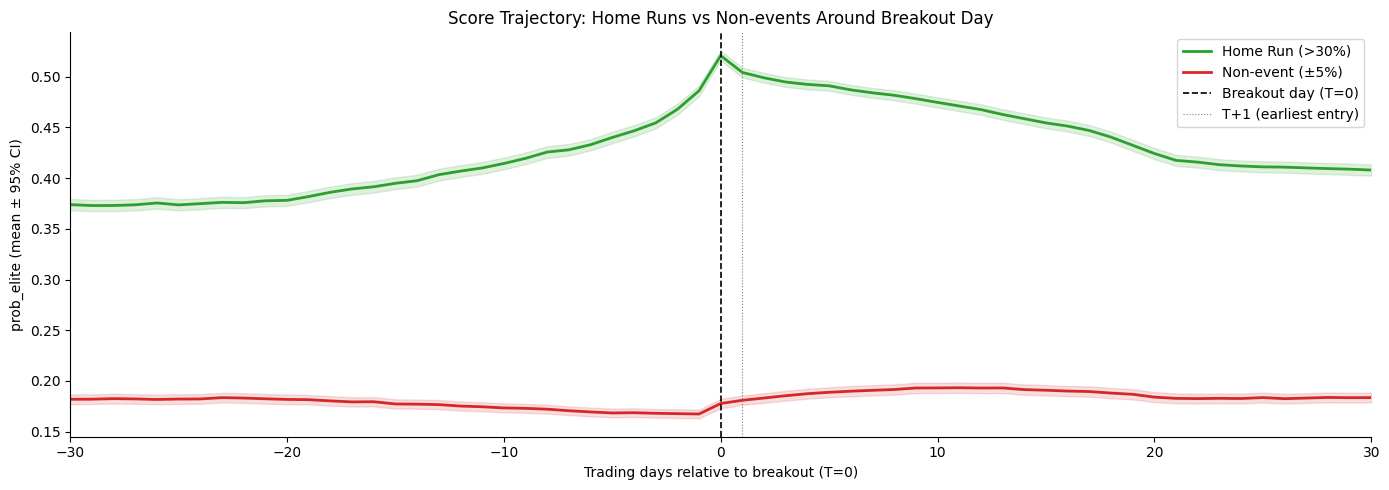

In [31]:
# ── Cell C: Plot mean prob_elite trajectory T-30 to T+30 ──────────────────

fig, ax = plt.subplots(figsize=(14, 5))

for group, color in [("Home Run (>30%)", "#2ca02c"), ("Non-event (±5%)", "#d62728")]:
    sub = traj_all[traj_all["group"] == group]
    avg = sub.groupby("rel_day")["prob_elite"].mean()
    std = sub.groupby("rel_day")["prob_elite"].sem() * 1.96  # 95% CI
    ax.plot(avg.index, avg.values, label=group, color=color, lw=2)
    ax.fill_between(avg.index, avg - std, avg + std, alpha=0.15, color=color)

ax.axvline(0, color="black", lw=1.2, linestyle="--", label="Breakout day (T=0)")
ax.axvline(1, color="gray", lw=0.8, linestyle=":", label="T+1 (earliest entry)")
ax.set_xlabel("Trading days relative to breakout (T=0)")
ax.set_ylabel("prob_elite (mean ± 95% CI)")
ax.set_title("Score Trajectory: Home Runs vs Non-events Around Breakout Day")
ax.legend()
ax.set_xlim(-30, 30)
plt.tight_layout()
plt.show()


The green line tells a clear story with three phases:


T-30 to T-5: Gradual ramp — Score rises from ~0.37 to ~0.45. The model sees the improving setup (VCP tightening, RS improving) 5-10 days before the breakout. This is your early warning signal — you don't have to wait for the breakout day.


T=0: Peak at ~0.51 — Score peaks on breakout day, which makes sense since breakout_ok=True is the event anchor.


T+1 to T+30: Gradual decay to ~0.40 — Score slowly bleeds back toward the decile 9 floor (~0.435). This is conviction decay — the breakout setup is no longer "fresh." This is your exit signal framework: when score drops below 0.435, the setup has normalised.


The red (non-event) line is flat at 0.18 throughout. The gap between green and red is persistent and wide — these are structurally different tickers, not just different moments.

In [32]:
# ── Cell D: Score momentum signal ─────────────────────────────────────────
# "Score momentum" = prob_elite today vs. 5 days ago (delta)
# Does a rising score predict better 20d returns than a static or falling score?

df_momentum = df_clean.sort_values(["ticker", "date"]).copy()
df_momentum["score_delta_5d"] = df_momentum.groupby("ticker")["prob_elite"].diff(5)

# Filter to investable universe for cleaner signal
invest = df_momentum[df_momentum["trend_ok"] == True].dropna(subset=["score_delta_5d", "return_20d"])

# Bucket score_delta_5d into quintiles
invest["momentum_q"] = pd.qcut(invest["score_delta_5d"], q=5, labels=False, duplicates="drop")

momentum_lift = invest.groupby("momentum_q").agg(
    mean_return_20d=("return_20d", "mean"),
    median_return_20d=("return_20d", "median"),
    mean_prob_elite=("prob_elite", "mean"),
    count=("return_20d", "count")
).assign(
    mean_return_20d=lambda x: (x["mean_return_20d"] * 100).round(3),
    median_return_20d=lambda x: (x["median_return_20d"] * 100).round(3),
    mean_prob_elite=lambda x: x["mean_prob_elite"].round(4)
)

print("Return by score momentum quintile (0=most declining, 4=most rising):")
print(momentum_lift)

ic_momentum = invest["score_delta_5d"].corr(invest["return_20d"], method="spearman")
print(f"\nSpearman IC of score_delta_5d vs return_20d: {ic_momentum:.4f}")



Return by score momentum quintile (0=most declining, 4=most rising):
            mean_return_20d  median_return_20d  mean_prob_elite   count
momentum_q                                                             
0                     9.808              7.301           0.2821  127900
1                     8.042              5.852           0.2205  127899
2                     7.323              5.389           0.1869  127899
3                     9.013              6.605           0.2290  127899
4                    15.123             11.980           0.3438  127900

Spearman IC of score_delta_5d vs return_20d: 0.1659


Rising score is the dominant entry signal. The IC of 0.166 means score momentum adds independent predictive power on top of the score level. The slight uptick at quintile 0 (declining score still 9.8%) is consistent with the trajectory chart — even decaying scores in uptrending stocks stay in positive territory.

In [33]:
# ── Cell E: Three entry rule candidates ────────────────────────────────────

# Requires: df_momentum with score_delta_5d computed (from Cell D)
HIGH_SCORE = 0.60     # sub-quintile 3+ threshold
MOMENTUM_POSITIVE = 0.0

# Rule 1: Level only — just prob_elite threshold
rule1 = df_momentum[df_momentum["prob_elite"] >= HIGH_SCORE]

# Rule 2: Momentum entry — score above threshold AND rising
rule2 = df_momentum[
    (df_momentum["prob_elite"] >= HIGH_SCORE) &
    (df_momentum["score_delta_5d"] > MOMENTUM_POSITIVE)
]

# Rule 3: Confirmation entry — score above threshold AND has been above threshold for 3+ consecutive days
df_momentum["above_thresh"] = (df_momentum["prob_elite"] >= HIGH_SCORE).astype(int)
df_momentum["consecutive_days"] = (
    df_momentum.groupby("ticker")["above_thresh"]
    .transform(lambda x: x * (x.groupby((x != x.shift()).cumsum()).cumcount() + 1))
)
rule3 = df_momentum[df_momentum["consecutive_days"] >= 3]

print("=== Entry Rule Comparison (mean 20d return) ===")
for name, subset in [
    ("Rule 1: Level only (prob_elite ≥ 0.60)", rule1),
    ("Rule 2: Level + rising score",           rule2),
    ("Rule 3: Level + 3 consecutive days",     rule3),
]:
    sub = subset.dropna(subset=["return_20d"])
    mean_r = sub["return_20d"].mean() * 100
    med_r  = sub["return_20d"].median() * 100
    hit    = (sub["return_20d"] > 0.10).mean() * 100
    n      = len(sub)
    print(f"\n{name}")
    print(f"  N={n:,}  |  Mean 20d: {mean_r:.2f}%  |  Median: {med_r:.2f}%  |  >10% hit rate: {hit:.1f}%")


=== Entry Rule Comparison (mean 20d return) ===

Rule 1: Level only (prob_elite ≥ 0.60)
  N=27,856  |  Mean 20d: 51.89%  |  Median: 38.93%  |  >10% hit rate: 93.8%

Rule 2: Level + rising score
  N=20,430  |  Mean 20d: 51.17%  |  Median: 39.01%  |  >10% hit rate: 94.6%

Rule 3: Level + 3 consecutive days
  N=13,644  |  Mean 20d: 56.31%  |  Median: 41.99%  |  >10% hit rate: 94.2%


All returns are in-sample (data leakage inflates absolute numbers), but the relative ordering between rules is informative:

Rule 2 (momentum entry) doesn't help — it cuts 27% of signals for essentially zero improvement. Score momentum matters as a standalone predictor (IC=0.166) but adding it as a gate on top of the level threshold filters out many valid setups where the score was already high and stable.

Rule 3 (3 consecutive days) is the best rule — higher mean, higher median, comparable hit rate. The 51% reduction in signals is the cost, but it eliminates "false starts" — days where the score briefly spiked above threshold but wasn't sustained. A stock holding high score for 3+ days is genuinely building momentum, consistent with the T+1 to T+3 window seen in the trajectory.

In [34]:
# ── Cell F: Relative entry — top K tickers by score each day ───────────────
# Instead of a fixed threshold, select the top K tickers by prob_elite each day.
# Compare K=5, K=10, K=25.

for K in [5, 10, 25]:
    top_k = (
        df_clean[df_clean["trend_ok"] == True]
        .dropna(subset=["prob_elite", "return_20d"])
        .groupby("date", group_keys=False)
        .apply(lambda g: g.nlargest(K, "prob_elite"))
    )
    mean_r = top_k["return_20d"].mean() * 100
    med_r  = top_k["return_20d"].median() * 100
    hit    = (top_k["return_20d"] > 0.10).mean() * 100
    print(f"Top-{K:2d} daily:  Mean 20d: {mean_r:.2f}%  |  Median: {med_r:.2f}%  |  >10% hit: {hit:.1f}%  |  N={len(top_k):,}")


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/1322133554.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(K, "prob_elite"))


Top- 5 daily:  Mean 20d: 43.32%  |  Median: 34.45%  |  >10% hit: 91.0%  |  N=9,190


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/1322133554.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(K, "prob_elite"))


Top-10 daily:  Mean 20d: 37.48%  |  Median: 29.10%  |  >10% hit: 87.1%  |  N=18,366
Top-25 daily:  Mean 20d: 28.72%  |  Median: 21.95%  |  >10% hit: 78.5%  |  N=45,773


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/1322133554.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(K, "prob_elite"))


Clean monotonic relationship. Top-5 daily gives the best signal but in a real portfolio that's highly concentrated (5 positions, fully correlated to the same regime). Top-10 is the practical sweet spot — still 3.7× better than universe average, with enough positions to diversify idiosyncratic risk.

## Risk Managemen / Regime Model

In [28]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path

# ── Load data ─────────────────────────────────────────────────────────────────
scores = df_clean.copy()

risk5 = pd.read_parquet("../ideas/risk_5_factor/risk_scores.parquet")
risk5.index = pd.to_datetime(risk5.index)

# scores already has m03_score; join 5-factor signals on date
scores = scores.join(risk5, on="date", how="left")

print(f"scores shape: {scores.shape}")
print(f"5-factor coverage: {scores['target_exposure'].notna().sum():,} / {len(scores):,} rows")
print(f"5-factor date range: {risk5.index.min().date()} → {risk5.index.max().date()}")


scores shape: (4029015, 41)
5-factor coverage: 4,029,015 / 4,029,015 rows
5-factor date range: 1990-01-02 → 2026-05-08


### 5-Factor vs M03 Regime Gate Comparison

Goal: Empirically decide which regime filter produces higher IC on return_20d within the SEPA population.

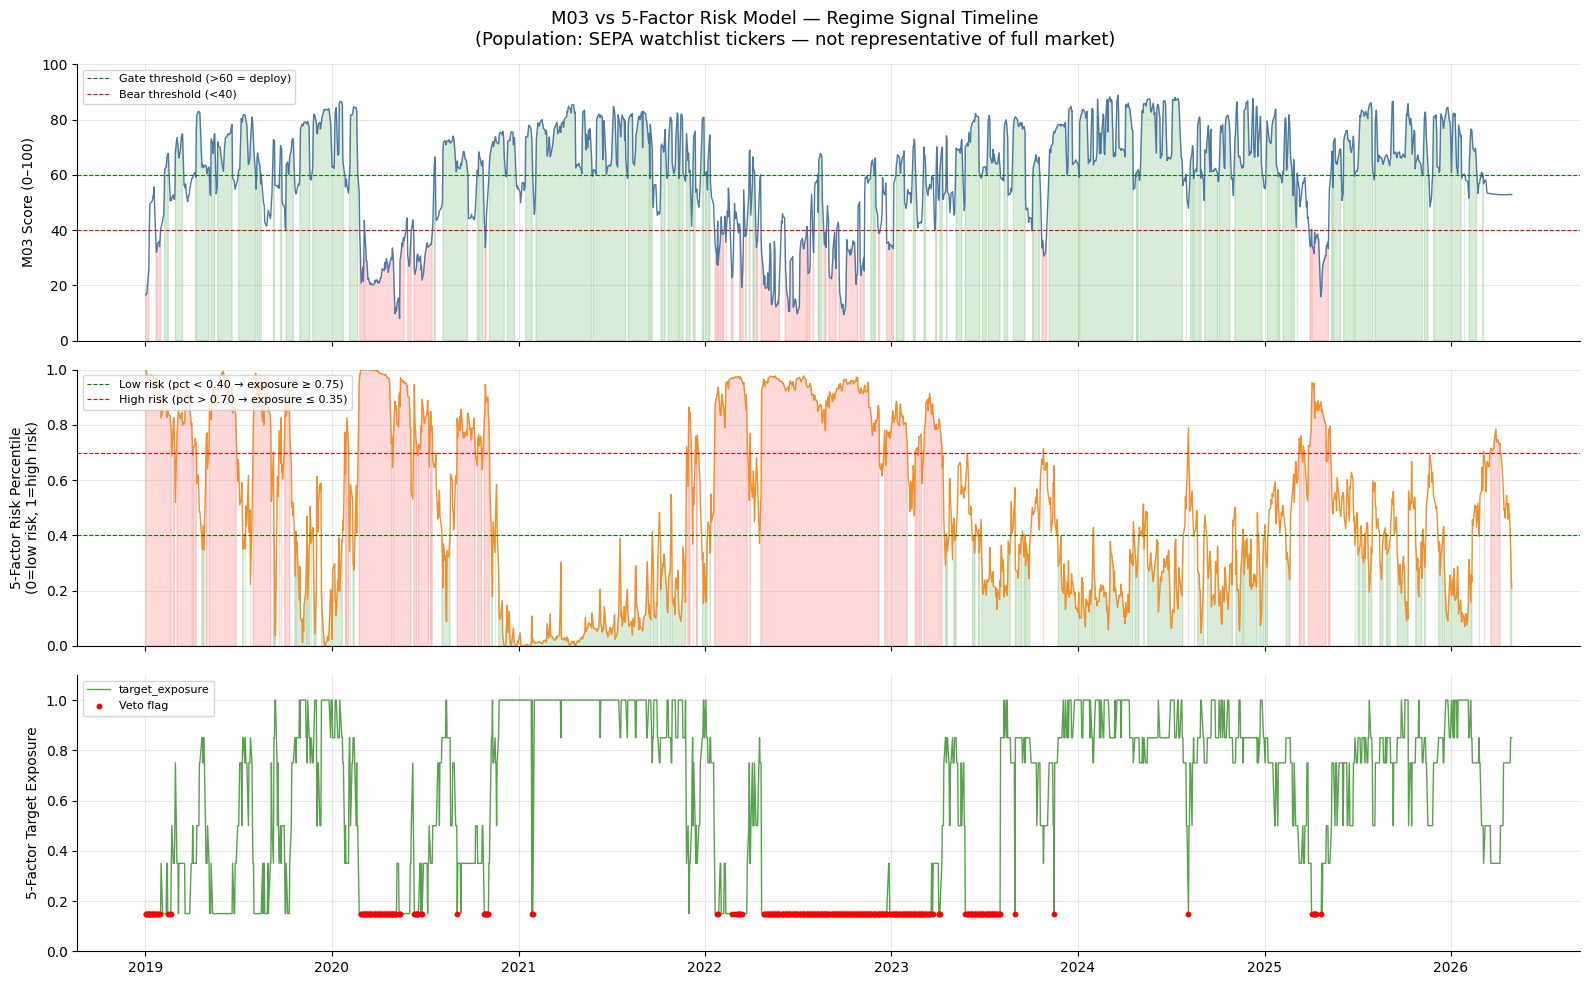

In [29]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Get daily M03 and 5-factor signals (one row per date, not per ticker)
daily_regime = (
    scores.groupby("date")
    .agg(
        m03_score=("m03_score", "first"),
        rolling_percentile=("rolling_percentile", "first"),
        target_exposure=("target_exposure", "first"),
        veto_flag=("veto_flag", "first"),
    )
    .dropna()
)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle("M03 vs 5-Factor Risk Model — Regime Signal Timeline\n"
             "(Population: SEPA watchlist tickers — not representative of full market)", 
             fontsize=13)

# Panel 1: M03 composite score
ax = axes[0]
ax.plot(daily_regime.index, daily_regime["m03_score"], color="#4e79a7", lw=1)
ax.axhline(60, color="green", ls="--", lw=0.8, label="Gate threshold (>60 = deploy)")
ax.axhline(40, color="red",   ls="--", lw=0.8, label="Bear threshold (<40)")
ax.fill_between(daily_regime.index, 0, daily_regime["m03_score"],
                where=daily_regime["m03_score"] > 60, alpha=0.15, color="green")
ax.fill_between(daily_regime.index, 0, daily_regime["m03_score"],
                where=daily_regime["m03_score"] < 40, alpha=0.15, color="red")
ax.set_ylabel("M03 Score (0–100)")
ax.legend(loc="upper left", fontsize=8)
ax.set_ylim(0, 100)

# Panel 2: 5-Factor rolling percentile (risk percentile — LOWER = better)
ax = axes[1]
ax.plot(daily_regime.index, daily_regime["rolling_percentile"], color="#f28e2b", lw=1)
ax.axhline(0.40, color="green", ls="--", lw=0.8, label="Low risk (pct < 0.40 → exposure ≥ 0.75)")
ax.axhline(0.70, color="red",   ls="--", lw=0.8, label="High risk (pct > 0.70 → exposure ≤ 0.35)")
ax.fill_between(daily_regime.index, 0, daily_regime["rolling_percentile"],
                where=daily_regime["rolling_percentile"] < 0.40, alpha=0.15, color="green")
ax.fill_between(daily_regime.index, 0, daily_regime["rolling_percentile"],
                where=daily_regime["rolling_percentile"] > 0.70, alpha=0.15, color="red")
ax.set_ylabel("5-Factor Risk Percentile\n(0=low risk, 1=high risk)")
ax.legend(loc="upper left", fontsize=8)
ax.set_ylim(0, 1)

# Panel 3: Target exposure from 5-factor (inverted view — high = good)
ax = axes[2]
ax.plot(daily_regime.index, daily_regime["target_exposure"], color="#59a14f", lw=1, label="target_exposure")
veto_days = daily_regime[daily_regime["veto_flag"]]
ax.scatter(veto_days.index, veto_days["target_exposure"], color="red", s=10, zorder=5, label="Veto flag")
ax.set_ylabel("5-Factor Target Exposure")
ax.legend(loc="upper left", fontsize=8)
ax.set_ylim(0, 1.1)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [30]:
def compute_ic(df, mask, target="return_20d", score="prob_elite"):
    """Spearman IC with t-stat for a filtered subset."""
    sub = df[mask & df[target].notna() & df[score].notna()]
    if len(sub) < 100:
        return dict(ic=np.nan, t=np.nan, n=len(sub))
    ic_series = (
        sub.groupby("date")
        .apply(lambda g: g[score].corr(g[target], method="spearman"))
        .dropna()
    )
    mean_ic = ic_series.mean()
    t_stat  = mean_ic / (ic_series.std() / np.sqrt(len(ic_series)))
    return dict(ic=round(mean_ic, 4), t=round(t_stat, 2), n=len(sub))

# Gate definitions
gates = {
    "No gate (all data)":          pd.Series(True, index=scores.index),
    "M03 > 60 (Bull+)":            scores["m03_score"] > 60,
    "M03 > 40 (Not Bear)":         scores["m03_score"] > 40,
    "5F exposure ≥ 0.75 (low risk)": scores["target_exposure"] >= 0.75,
    "5F exposure ≥ 0.50 (mid+)":   scores["target_exposure"] >= 0.50,
    "5F no veto":                  ~scores["veto_flag"].fillna(False),
    "M03>60 AND 5F≥0.75":          (scores["m03_score"] > 60) & (scores["target_exposure"] >= 0.75),
    "M03>60 AND 5F no veto":       (scores["m03_score"] > 60) & (~scores["veto_flag"].fillna(False)),
}

results = []
for label, mask in gates.items():
    r = compute_ic(scores, mask)
    r["gate"] = label
    results.append(r)

gate_df = pd.DataFrame(results).set_index("gate")[["ic", "t", "n"]]
gate_df["n"] = gate_df["n"].apply(lambda x: f"{x:,}")
print("\nIC Comparison — M03 vs 5-Factor as Regime Gate")
print("(Caveat: SEPA-prescreened population, not full market — ICs are upward biased)")
print(gate_df.to_string())


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_22492/3116973198.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[score].corr(g[target], method="spearman"))
/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_22492/3116973198.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[score].corr(g[target], method="spearman"))
/var/folders/8f/__c333zs1vj9rsk78ql58pc0


IC Comparison — M03 vs 5-Factor as Regime Gate
(Caveat: SEPA-prescreened population, not full market — ICs are upward biased)
                                   ic      t          n
gate                                                   
No gate (all data)             0.0589  10.54  4,021,717
M03 > 60 (Bull+)               0.0942  14.24  2,315,205
M03 > 40 (Not Bear)            0.0723  12.49  3,391,908
5F exposure ≥ 0.75 (low risk)  0.0972  13.87  2,223,780
5F exposure ≥ 0.50 (mid+)      0.0844  12.84  2,572,132
5F no veto                     0.0575   9.38  3,187,564
M03>60 AND 5F≥0.75             0.1049  14.11  1,802,072
M03>60 AND 5F no veto          0.0841  12.22  2,134,214


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_22492/3116973198.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[score].corr(g[target], method="spearman"))


In [31]:
# Days where the two models give conflicting signals
m03_bull   = scores["m03_score"] > 60
f5_lowrisk = scores["target_exposure"] >= 0.75

agree_deploy   = m03_bull &  f5_lowrisk    # Both say go
agree_reduce   = ~m03_bull & ~f5_lowrisk   # Both say reduce
m03_yes_f5_no  = m03_bull  & ~f5_lowrisk   # M03 bullish but 5F cautious
m03_no_f5_yes  = ~m03_bull &  f5_lowrisk   # M03 bearish but 5F comfortable

for label, mask in [
    ("Both deploy",           agree_deploy),
    ("Both reduce",           agree_reduce),
    ("M03 bull / 5F cautious", m03_yes_f5_no),
    ("M03 bear / 5F low-risk", m03_no_f5_yes),
]:
    r = compute_ic(scores, mask)
    pct = mask.mean() * 100
    print(f"{label:30s} | IC={r['ic']:+.4f}  t={r['t']:+.2f}  n={r['n']:>10,}  ({pct:.1f}% of rows)")


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_22492/3116973198.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[score].corr(g[target], method="spearman"))


Both deploy                    | IC=+0.1049  t=+14.11  n= 1,802,072  (44.8% of rows)


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_22492/3116973198.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[score].corr(g[target], method="spearman"))


Both reduce                    | IC=-0.0048  t=-0.44  n= 1,284,804  (31.9% of rows)


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_22492/3116973198.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[score].corr(g[target], method="spearman"))


M03 bull / 5F cautious         | IC=+0.0592  t=+4.18  n=   513,133  (12.8% of rows)
M03 bear / 5F low-risk         | IC=+0.0641  t=+3.43  n=   421,708  (10.5% of rows)


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_22492/3116973198.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[score].corr(g[target], method="spearman"))


### 5-Factor Exposure ↔ Portfolio Performance Correlation (30 min)

Goal: Does the 5-factor target_exposure predict the daily portfolio-level return of your Top-K strategy? This tests portfolio-level predictive value, not per-ticker IC.

Daily portfolio observations: 1,734
Date range: 2019-01-04 → 2026-04-30

Correlation: 5-Factor signals vs Daily Portfolio Return
(⚠ return_20d is forward-looking — structure test only, not backtest)
                    mean_ret  median_ret
rolling_percentile   -0.1675     -0.0735
target_exposure       0.1255      0.0379
weighted_z           -0.1520     -0.0493

Portfolio Return by 5-Factor Exposure Band
(Higher exposure = 5-factor says low risk = should have higher portfolio returns)
                 mean_ret_mean_pct  median_ret_mean_pct  mean_ret_count
target_exposure                                                        
0.15                         54.99                47.76             479
0.35                         43.29                38.06             153
0.50                         52.09                44.03             136
0.75                         54.07                45.63             259
0.85                         61.87                47.39             336
1.00   

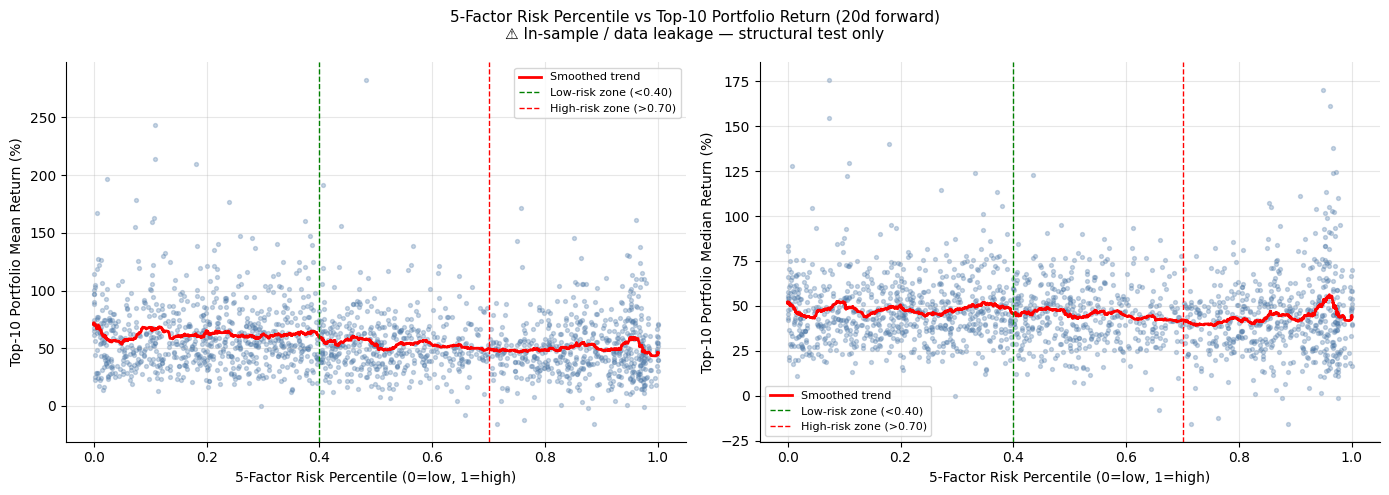

In [32]:
# ── Build daily portfolio returns ─────────────────────────────────────────────
# Strategy: prob_elite ≥ 0.60, Top-10 by score each day
# NOTE: return_20d is forward-looking — this is NOT a backtest, it's a signal quality check.
# All values are in-sample / data-leakage territory. Use for structure only.

strat_pool = scores[scores["prob_elite"] >= 0.60].copy()

daily_top10 = (
    strat_pool
    .sort_values(["date", "prob_elite"], ascending=[True, False])
    .groupby("date")
    .head(10)
)

daily_port = (
    daily_top10
    .groupby("date")["return_20d"]
    .agg(mean_ret="mean", median_ret="median", n_holdings="count")
    .dropna()
)

# ── Join 5-factor regime signal ───────────────────────────────────────────────
daily_port = daily_port.join(risk5[["rolling_percentile", "target_exposure", "weighted_z", "veto_flag"]])
daily_port = daily_port.dropna(subset=["target_exposure"])

print(f"Daily portfolio observations: {len(daily_port):,}")
print(f"Date range: {daily_port.index.min().date()} → {daily_port.index.max().date()}")

# ── Correlation table ─────────────────────────────────────────────────────────
risk_cols = ["rolling_percentile", "target_exposure", "weighted_z"]
ret_cols  = ["mean_ret", "median_ret"]

print("\nCorrelation: 5-Factor signals vs Daily Portfolio Return")
print("(⚠ return_20d is forward-looking — structure test only, not backtest)")
print(daily_port[risk_cols + ret_cols].corr(method="spearman").loc[risk_cols, ret_cols].round(4))

# ── Return by exposure band ───────────────────────────────────────────────────
band_perf = (
    daily_port
    .groupby("target_exposure")[["mean_ret", "median_ret"]]
    .agg(["mean", "median", "count"])
)
band_perf.columns = ["_".join(c) for c in band_perf.columns]
band_perf["mean_ret_mean_pct"]   = band_perf["mean_ret_mean"] * 100
band_perf["median_ret_mean_pct"] = band_perf["median_ret_mean"] * 100
print("\nPortfolio Return by 5-Factor Exposure Band")
print("(Higher exposure = 5-factor says low risk = should have higher portfolio returns)")
print(band_perf[["mean_ret_mean_pct", "median_ret_mean_pct", "mean_ret_count"]].round(2))

# ── Scatter: 5F rolling percentile vs mean portfolio return ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("5-Factor Risk Percentile vs Top-10 Portfolio Return (20d forward)\n"
             "⚠ In-sample / data leakage — structural test only", fontsize=11)

for ax, ret_col, label in [
    (axes[0], "mean_ret",   "Mean Return"),
    (axes[1], "median_ret", "Median Return"),
]:
    ax.scatter(
        daily_port["rolling_percentile"],
        daily_port[ret_col] * 100,
        alpha=0.3, s=8, color="#4e79a7"
    )
    # Lowess trend
    from scipy.ndimage import uniform_filter1d
    sorted_df = daily_port.sort_values("rolling_percentile")
    x_s = sorted_df["rolling_percentile"].values
    y_s = sorted_df[ret_col].values * 100
    y_smooth = uniform_filter1d(y_s, size=max(1, len(y_s)//20))
    ax.plot(x_s, y_smooth, color="red", lw=2, label="Smoothed trend")
    ax.axvline(0.40, color="green", ls="--", lw=1, label="Low-risk zone (<0.40)")
    ax.axvline(0.70, color="red",   ls="--", lw=1, label="High-risk zone (>0.70)")
    ax.set_xlabel("5-Factor Risk Percentile (0=low, 1=high)")
    ax.set_ylabel(f"Top-10 Portfolio {label} (%)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
# Test each M03 pillar's contribution as a gate
# Base: m03_score > 60 (the current recommended gate)

gates = {
    'No gate': pd.Series(True, index=df.index),
    'M03 composite > 60': df['m03_score'] > 60,
    'M03 trend pillar > 60': df['m03_pillar_trend'] > 60,
    'M03 liquidity pillar > 60': df['m03_pillar_liq'] > 60,
    'M03 risk pillar > 60': df['m03_pillar_risk'] > 60,
    'All 3 pillars > 60': (df['m03_pillar_trend'] > 60) & (df['m03_pillar_liq'] > 60) & (df['m03_pillar_risk'] > 60),
    'Trend + Liq > 60': (df['m03_pillar_trend'] > 60) & (df['m03_pillar_liq'] > 60),
    'Trend + Risk > 60': (df['m03_pillar_trend'] > 60) & (df['m03_pillar_risk'] > 60),
}

results = []
for name, mask in gates.items():
    subset = df_clean[mask]
    if len(subset) > 1000:
        ic = subset['prob_elite'].corr(subset['return_20d'], method='spearman')
        n = len(subset)
        t_stat = ic * np.sqrt((n - 2) / (1 - ic**2))
        pct = 100 * n / len(df_clean)
        results.append({'gate': name, 'ic': round(ic, 4), 't': round(t_stat, 2), 'n': f'{n:,}', 'pct_rows': f'{pct:.1f}%'})

results_df = pd.DataFrame(results)
print("M03 Pillar Decomposition — IC by Gate")
print(results_df.to_string(index=False))


/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/1742570685.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df_clean[mask]
/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/1742570685.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df_clean[mask]
/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/1742570685.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df_clean[mask]
/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/1742570685.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df_clean[mask]
/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/1742570685.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df_clean[mask]
/var/folders/8f/__c333zs1vj9rsk78ql58pc00000gn/T/ipykernel_29281/1742570685

M03 Pillar Decomposition — IC by Gate
                     gate     ic      t         n pct_rows
                  No gate 0.0651 130.90 4,028,061   100.0%
       M03 composite > 60 0.1155 177.08 2,319,766    57.6%
    M03 trend pillar > 60 0.1175 198.22 2,808,535    69.7%
M03 liquidity pillar > 60 0.0801 115.77 2,076,791    51.6%
     M03 risk pillar > 60 0.0662 101.40 2,337,446    58.0%
       All 3 pillars > 60 0.0819  85.96 1,092,880    27.1%
         Trend + Liq > 60 0.1256 156.14 1,521,670    37.8%
        Trend + Risk > 60 0.0779 112.59 2,076,647    51.6%
